In [1]:
import pandas as pd

df = pd.read_csv("../data/grievances.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (614, 3)


,grievance_id,text,category
0,GRVH900075,"Sir/Madam, Patna mein bijli two weeks se gayab...",Electricity
1,GRVH900500,"Namaste sir, Ration dealer Adhartal mein har m...",Corruption & Bribery
2,GRVH900036,"Drinking water contaminated hai Sector 7 mein,...",Water Supply
3,GRVH900436,Passbook update Model Town bank branch mein tw...,Banking & Financial Services
4,GRVH900160,"महोदय, Mohd. Salim ki pension 3 days se nahi m...",Pension & Provident Fund


In [2]:
print(df.columns.tolist())

['grievance_id', 'text', 'category']


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   grievance_id  614 non-null    str  
 1   text          614 non-null    str  
 2   category      614 non-null    str  
dtypes: str(3)
memory usage: 14.5 KB


In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
grievance_id    0
text            0
category        0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate complaint texts:", df["text"].duplicated().sum())

Duplicate rows: 0
Duplicate complaint texts: 0


In [6]:
print("Number of categories:", df["category"].nunique())
print("\nCategory distribution:")
print(df["category"].value_counts())

Number of categories: 14

Category distribution:
category
Corruption & Bribery                   50
Land Records & Revenue                 50
Employment & Labour                    50
Education & Schools                    48
Pension & Provident Fund               47
Banking & Financial Services           46
Police & Law and Order                 46
Healthcare & Hospitals                 45
Water Supply                           43
Ration & Public Distribution System    41
Sanitation & Garbage                   39
Electricity                            37
Municipal Certificates                 36
Roads & Infrastructure                 36
Name: count, dtype: int64


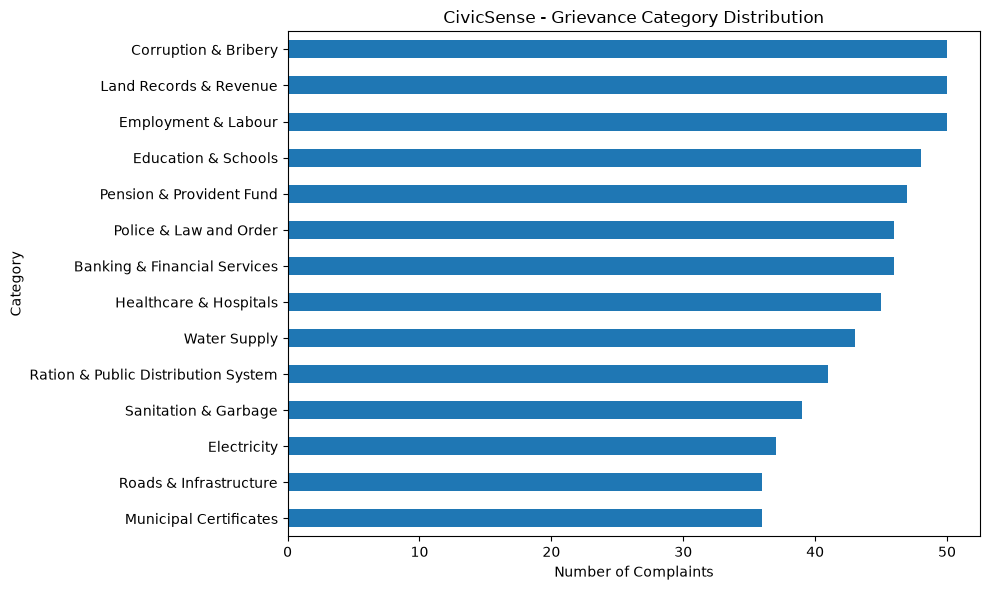

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

df["category"].value_counts().sort_values().plot(kind="barh")

plt.xlabel("Number of Complaints")
plt.ylabel("Category")
plt.title("CivicSense - Grievance Category Distribution")

plt.tight_layout()
plt.show()

In [8]:
import re

def detect_script(text):
    text = str(text)

    has_devanagari = bool(re.search(r'[\u0900-\u097F]', text))
    has_latin = bool(re.search(r'[A-Za-z]', text))

    if has_devanagari and has_latin:
        return "Mixed"
    elif has_devanagari:
        return "Hindi Script"
    elif has_latin:
        return "Roman / English-Hinglish"
    else:
        return "Other"

df["script_type"] = df["text"].apply(detect_script)

print(df["script_type"].value_counts())

script_type
Roman / English-Hinglish    355
Mixed                       259
Name: count, dtype: int64


In [9]:
print("Roman / English-Hinglish examples:\n")

for text in df[df["script_type"] == "Roman / English-Hinglish"]["text"].head(5):
    print("-", text)

print("\n" + "="*80)
print("Mixed examples:\n")

for text in df[df["script_type"] == "Mixed"]["text"].head(5):
    print("-", text)

Roman / English-Hinglish examples:

- Namaste sir, Ration dealer Adhartal mein har mahine paise leta hai anaj dene ke liye, complaint dena chahta hoon.
- Drinking water contaminated hai Sector 7 mein, please send sample testing team. Thank you.
- Passbook update Model Town bank branch mein two weeks se nahi ho raha, staff kaam nahi kar rahe. Bahut pareshaan hain hum log.
- Death certificate apply kiya tha one week pehle Ward 12 mein, abhi tak nhi mila. Otherwise we will protest.
- Ration dealer Indore mein har mahine paise leta hai anaj dene ke liye, complaint dena chahta hoon.

Mixed examples:

- Sir/Madam, Patna mein bijli two weeks se gayab h, transformer kharab ho gaya lagta hai. कृपया जल्द कार्रवाई करें।
- महोदय, Mohd. Salim ki pension 3 days se nahi mili hai, bank account Wright Town branch mein hai. कृपया जल्द कार्रवाई करें।
- Namaste sir, जमीन विवाद Patna में 3 days से पटवारी के पास लंबित है, कोई सुनवाई नहीं हो रही। Thank you.
- Namaste sir, जमीन विवाद Varanasi में 10 din से पट

In [10]:
df["text_length"] = df["text"].astype(str).str.len()

print(df["text_length"].describe())

count    614.000000
mean     115.197068
std       16.261683
min       71.000000
25%      104.000000
50%      116.000000
75%      127.000000
max      160.000000
Name: text_length, dtype: float64


In [11]:
print("Exact duplicate texts:", df["text"].duplicated().sum())

Exact duplicate texts: 0


In [12]:
text_category_check = df.groupby("text")["category"].nunique()

print(
    "Texts having multiple categories:",
    (text_category_check > 1).sum()
)

Texts having multiple categories: 0


In [13]:
import re

def clean_text(text):
    text = str(text)
    
    # Extra spaces remove
    text = re.sub(r"\s+", " ", text)
    
    # Starting/ending spaces remove
    text = text.strip()
    
    return text

df["clean_text"] = df["text"].apply(clean_text)

print(df[["text", "clean_text"]].head())

                                                text  \
0  Sir/Madam, Patna mein bijli two weeks se gayab...   
1  Namaste sir, Ration dealer Adhartal mein har m...   
2  Drinking water contaminated hai Sector 7 mein,...   
3  Passbook update Model Town bank branch mein tw...   
4  महोदय, Mohd. Salim ki pension 3 days se nahi m...   

                                          clean_text  
0  Sir/Madam, Patna mein bijli two weeks se gayab...  
1  Namaste sir, Ration dealer Adhartal mein har m...  
2  Drinking water contaminated hai Sector 7 mein,...  
3  Passbook update Model Town bank branch mein tw...  
4  महोदय, Mohd. Salim ki pension 3 days se nahi m...  


In [14]:
print("Empty cleaned texts:", (df["clean_text"] == "").sum())

Empty cleaned texts: 0


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2)
)

X_temp = vectorizer.fit_transform(df["clean_text"])

print("TF-IDF matrix shape:", X_temp.shape)

TF-IDF matrix shape: (614, 1992)


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df["clean_text"])

print("TF-IDF matrix shape:", X.shape)
print("Number of features:", len(tfidf.get_feature_names_out()))

TF-IDF matrix shape: (614, 1992)
Number of features: 1992


In [19]:
y = df["category"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nCategories:", y.nunique())

X shape: (614, 1992)
y shape: (614,)

Categories: 14


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 491
Testing samples: 123


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2)
)

X_train = tfidf.fit_transform(df.loc[y_train.index, "clean_text"])
X_test = tfidf.transform(df.loc[y_test.index, "clean_text"])

print("Training TF-IDF shape:", X_train.shape)
print("Testing TF-IDF shape:", X_test.shape)

Training TF-IDF shape: (491, 1847)
Testing TF-IDF shape: (123, 1847)


In [22]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [23]:
y_pred_lr = lr_model.predict(X_test)

print("Predictions generated:", len(y_pred_lr))

Predictions generated: 123


In [25]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average="macro")
recall = recall_score(y_test, y_pred_lr, average="macro")
f1 = f1_score(y_test, y_pred_lr, average="macro")

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"Macro F1  : {f1:.4f}")

Logistic Regression Results
---------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro F1  : 1.0000


In [26]:
results = {
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "Macro F1": [f1]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,Macro F1
0,Logistic Regression,1.0,1.0,1.0,1.0


<Figure size 1200x1000 with 0 Axes>

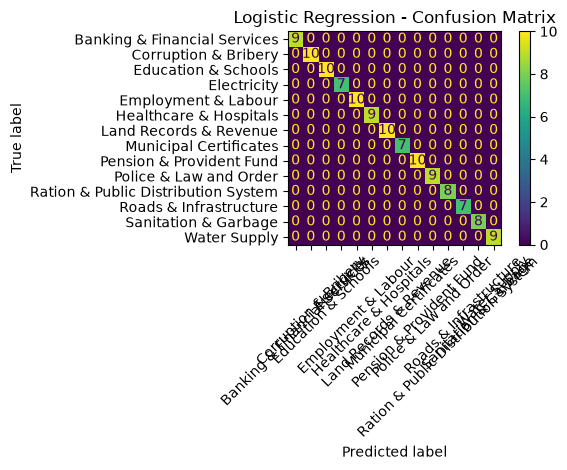

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    xticks_rotation=45
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

similarity_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2)
)

X_similarity = similarity_vectorizer.fit_transform(df["clean_text"])

similarity_matrix = cosine_similarity(X_similarity)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (614, 614)


In [30]:
import numpy as np

# Diagonal (same complaint with itself) ignore karo
similarity_matrix_no_diag = similarity_matrix.copy()
np.fill_diagonal(similarity_matrix_no_diag, 0)

threshold = 0.80

similar_pairs = np.argwhere(
    similarity_matrix_no_diag >= threshold
)

print("Similar complaint pairs:", len(similar_pairs))

Similar complaint pairs: 256


In [32]:
thresholds = [0.70, 0.80, 0.90, 0.95]

for threshold in thresholds:
    matrix = similarity_matrix.copy()
    np.fill_diagonal(matrix, 0)

    pairs = np.argwhere(matrix >= threshold)

    print(f"Threshold {threshold}: {len(pairs)} pairs")

Threshold 0.7: 1588 pairs
Threshold 0.8: 256 pairs
Threshold 0.9: 12 pairs
Threshold 0.95: 4 pairs


In [33]:
pairs = np.argwhere(similarity_matrix_no_diag >= 0.80)

shown = set()
count = 0

for i, j in pairs:
    pair = tuple(sorted((i, j)))

    if pair in shown:
        continue

    shown.add(pair)

    print("\nSimilarity:", round(similarity_matrix[i, j], 3))
    print("A:", df.iloc[i]["clean_text"])
    print("B:", df.iloc[j]["clean_text"])

    count += 1

    if count == 10:
        break


Similarity: 0.839
A: Namaste sir, Ration dealer Adhartal mein har mahine paise leta hai anaj dene ke liye, complaint dena chahta hoon.
B: Ration dealer Indore mein har mahine paise leta hai anaj dene ke liye, complaint dena chahta hoon.

Similarity: 0.803
A: Namaste sir, Ration dealer Adhartal mein har mahine paise leta hai anaj dene ke liye, complaint dena chahta hoon.
B: Respected Sir, Ration dealer Gwalior mein har mahine paise leta hai anaj dene ke liye, complaint dena chahta hoon. Kripya jald samadhan karein.

Similarity: 0.802
A: Namaste sir, Ration dealer Adhartal mein har mahine paise leta hai anaj dene ke liye, complaint dena chahta hoon.
B: Ration dealer Sector 7 mein har mahine paise leta hai anaj dene ke liye, complaint dena chahta hoon. Thank you.

Similarity: 0.805
A: Ration dealer Indore mein har mahine paise leta hai anaj dene ke liye, complaint dena chahta hoon.
B: Ration dealer Gandhi Nagar mein har mahine paise leta hai anaj dene ke liye, complaint dena chahta hoon.

In [36]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

# Similarity threshold
threshold = 0.80

# Union-Find setup
parent = list(range(len(df)))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    root_a = find(a)
    root_b = find(b)

    if root_a != root_b:
        parent[root_b] = root_a

# Similar complaints ko same group mein connect karo
for i, j in np.argwhere(similarity_matrix_no_diag >= threshold):
    union(i, j)

# Final group IDs
groups = [find(i) for i in range(len(df))]

df["template_group"] = groups

print("Total complaints:", len(df))
print("Unique template groups:", df["template_group"].nunique())

Total complaints: 614
Unique template groups: 506


In [38]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        df["clean_text"],
        df["category"],
        groups=df["template_group"]
    )
)

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

print("\nTraining categories:")
print(train_df["category"].value_counts())

print("\nTesting categories:")
print(test_df["category"].value_counts())

Training samples: 494
Testing samples: 120

Training categories:
category
Land Records & Revenue                 44
Corruption & Bribery                   42
Employment & Labour                    41
Pension & Provident Fund               38
Banking & Financial Services           37
Education & Schools                    36
Healthcare & Hospitals                 36
Police & Law and Order                 36
Electricity                            34
Water Supply                           32
Roads & Infrastructure                 30
Sanitation & Garbage                   30
Municipal Certificates                 29
Ration & Public Distribution System    29
Name: count, dtype: int64

Testing categories:
category
Education & Schools                    12
Ration & Public Distribution System    12
Water Supply                           11
Police & Law and Order                 10
Banking & Financial Services            9
Employment & Labour                     9
Healthcare & Hospitals        

In [39]:
print("Testing categories:")
print(test_df["category"].value_counts())

print("\nNumber of test categories:",
      test_df["category"].nunique())

Testing categories:
category
Education & Schools                    12
Ration & Public Distribution System    12
Water Supply                           11
Police & Law and Order                 10
Banking & Financial Services            9
Employment & Labour                     9
Healthcare & Hospitals                  9
Pension & Provident Fund                9
Sanitation & Garbage                    9
Corruption & Bribery                    8
Municipal Certificates                  7
Land Records & Revenue                  6
Roads & Infrastructure                  6
Electricity                             3
Name: count, dtype: int64

Number of test categories: 14


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_group = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2)
)

X_train_group = tfidf_group.fit_transform(train_df["clean_text"])
X_test_group = tfidf_group.transform(test_df["clean_text"])

y_train_group = train_df["category"]
y_test_group = test_df["category"]

print("Training TF-IDF shape:", X_train_group.shape)
print("Testing TF-IDF shape:", X_test_group.shape)

Training TF-IDF shape: (494, 1849)
Testing TF-IDF shape: (120, 1849)


In [41]:
from sklearn.linear_model import LogisticRegression

lr_group = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_group.fit(X_train_group, y_train_group)

y_pred_group = lr_group.predict(X_test_group)

print("Group-based Logistic Regression completed!")

Group-based Logistic Regression completed!


In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_group = accuracy_score(y_test_group, y_pred_group)
precision_group = precision_score(
    y_test_group, y_pred_group, average="macro"
)
recall_group = recall_score(
    y_test_group, y_pred_group, average="macro"
)
f1_group = f1_score(
    y_test_group, y_pred_group, average="macro"
)

print("Template-Aware Logistic Regression")
print("-----------------------------------")
print(f"Accuracy  : {accuracy_group:.4f}")
print(f"Precision : {precision_group:.4f}")
print(f"Recall    : {recall_group:.4f}")
print(f"Macro F1  : {f1_group:.4f}")

Template-Aware Logistic Regression
-----------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro F1  : 1.0000


In [43]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train_group, y_train_group)

y_pred_svm = svm_model.predict(X_test_group)

print("Linear SVM training completed!")

Linear SVM training completed!


In [44]:
accuracy_svm = accuracy_score(y_test_group, y_pred_svm)
precision_svm = precision_score(
    y_test_group, y_pred_svm, average="macro"
)
recall_svm = recall_score(
    y_test_group, y_pred_svm, average="macro"
)
f1_svm = f1_score(
    y_test_group, y_pred_svm, average="macro"
)

print("Linear SVM Results")
print("------------------")
print(f"Accuracy  : {accuracy_svm:.4f}")
print(f"Precision : {precision_svm:.4f}")
print(f"Recall    : {recall_svm:.4f}")
print(f"Macro F1  : {f1_svm:.4f}")

Linear SVM Results
------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro F1  : 1.0000


In [45]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_group, y_train_group)

y_pred_nb = nb_model.predict(X_test_group)

print("Naive Bayes training completed!")

Naive Bayes training completed!


In [47]:
accuracy_nb = accuracy_score(y_test_group, y_pred_nb)
precision_nb = precision_score(y_test_group, y_pred_nb, average="macro")
recall_nb = recall_score(y_test_group, y_pred_nb, average="macro")
f1_nb = f1_score(y_test_group, y_pred_nb, average="macro")

print("Naive Bayes Results")
print("-------------------")
print(f"Accuracy  : {accuracy_nb:.4f}")
print(f"Precision : {precision_nb:.4f}")
print(f"Recall    : {recall_nb:.4f}")
print(f"Macro F1  : {f1_nb:.4f}")

Naive Bayes Results
-------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
Macro F1  : 1.0000


In [49]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2)
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

scores = cross_val_score(
    lr_pipeline,
    df["clean_text"],
    df["category"],
    cv=cv,
    scoring="f1_macro"
)

print("5-Fold Macro F1 Scores:")
print(scores)

print("\nMean Macro F1:", scores.mean())
print("Std:", scores.std())

5-Fold Macro F1 Scores:
[1. 1. 1. 1. 1.]

Mean Macro F1: 1.0
Std: 0.0


In [50]:
import transformers
import torch

print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

Transformers: 5.17.0
PyTorch: 2.14.0+cpu
GPU available: False


In [51]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "ai4bharat/IndicBERTv2-MLM-only"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully!")

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

c:\Users\Dhanshree\CivicSense\CivicSense\.venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Dhanshree\.cache\huggingface\hub\models--ai4bharat--IndicBERTv2-MLM-only. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 7.75MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Tokenizer loaded successfully!


In [ ]:
from transformers import AutoModelForSequenceClassification

# Get all categories
labels = sorted(df["category"].unique())

# Create label mappings
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

print("Number of categories:", len(labels))
print("\nLabels:")
for i, label in id2label.items():
    print(i, "->", label)

# Load IndicBERT for classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    label2id=label2id,
    id2label=id2label
)

print("\nIndicBERT model loaded successfully!")

Number of categories: 14

Labels:
0 -> Banking & Financial Services
1 -> Corruption & Bribery
2 -> Education & Schools
3 -> Electricity
4 -> Employment & Labour
5 -> Healthcare & Hospitals
6 -> Land Records & Revenue
7 -> Municipal Certificates
8 -> Pension & Provident Fund
9 -> Police & Law and Order
10 -> Ration & Public Distribution System
11 -> Roads & Infrastructure
12 -> Sanitation & Garbage
13 -> Water Supply


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.12GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those p


IndicBERT model loaded successfully!


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

In [53]:
train_bert = train_df[["clean_text", "category"]].copy()
test_bert = test_df[["clean_text", "category"]].copy()

train_bert["label"] = train_bert["category"].map(label2id)
test_bert["label"] = test_bert["category"].map(label2id)

train_encodings = tokenizer(
    train_bert["clean_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_bert["clean_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

print("Training samples:", len(train_bert))
print("Testing samples:", len(test_bert))
print("Tokenization completed!")

Training samples: 494
Testing samples: 120
Tokenization completed!


In [55]:
import torch
from torch.utils.data import Dataset

class GrievanceDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item


train_dataset = GrievanceDataset(
    train_encodings,
    train_bert["label"].tolist()
)

test_dataset = GrievanceDataset(
    test_encodings,
    test_bert["label"].tolist()
)

print("Train dataset:", len(train_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 494
Test dataset: 120


In [58]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.14.0+cpu
CUDA available: False


AssertionError: Torch not compiled with CUDA enabled

In [59]:
import sys
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: c:\Users\Dhanshree\CivicSense\CivicSense\.venv\Scripts\python.exe
PyTorch: 2.14.0+cpu
CUDA available: False


In [60]:
import sys

print(sys.executable)

!{sys.executable} -m pip uninstall torch torchvision torchaudio -y

c:\Users\Dhanshree\CivicSense\CivicSense\.venv\Scripts\python.exe
Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128


In [61]:
import sys

!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
  Using cached torch-2.11.0%2Bcu128-cp311-cp311-win_amd64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0%2Bcu128-cp311-cp311-win_amd64.whl.metadata (5.6 kB)
  Using cached torchaudio-2.11.0%2Bcu128-cp311-cp311-win_amd64.whl.metadata (7.0 kB)
Using cached torch-2.11.0%2Bcu128-cp311-cp311-win_amd64.whl (2753.1 MB)
Using cached torchvision-0.26.0%2Bcu128-cp311-cp311-win_amd64.whl (9.3 MB)
Using cached torchaudio-2.11.0%2Bcu128-cp311-cp311-win_amd64.whl (1.7 MB)

   ---------------------------------------- 0/3 [torchaudio]
   ---------------------------------------- 0/3 [torchaudio]
   ---------------------------------------- 0/3 [torchaudio]
   ---------------------------------------- 0/3 [torchaudio]
   ---------------------------------------- 0/3 [torchaudio]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [tor

In [1]:
import torch
import sys

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: c:\Users\Dhanshree\CivicSense\CivicSense\.venv\Scripts\python.exe
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


training_args = TrainingArguments(
    output_dir="./civicsense_indicbert",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=10,
    save_strategy="no",
    report_to="none",
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Starting IndicBERT training on GPU...")

trainer.train()

print("Training completed!")

NameError: name 'model' is not defined

In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "ai4bharat/IndicBERTv2-MLM-only"

labels = sorted(df["category"].unique())

label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    label2id=label2id,
    id2label=id2label
)

print("IndicBERT model loaded!")

NameError: name 'df' is not defined

In [5]:
import pandas as pd

df = pd.read_csv("../data/grievances.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (614, 3)
  grievance_id                                               text  \
0   GRVH900075  Sir/Madam, Patna mein bijli two weeks se gayab...   
1   GRVH900500  Namaste sir, Ration dealer Adhartal mein har m...   
2   GRVH900036  Drinking water contaminated hai Sector 7 mein,...   
3   GRVH900436  Passbook update Model Town bank branch mein tw...   
4   GRVH900160  महोदय, Mohd. Salim ki pension 3 days se nahi m...   

                       category  
0                   Electricity  
1          Corruption & Bribery  
2                  Water Supply  
3  Banking & Financial Services  
4      Pension & Provident Fund  


In [6]:
import re
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from torch.utils.data import Dataset


# ============================================================
# 1. Prepare text
# ============================================================

if "clean_text" not in df.columns:
    def clean_text(text):
        text = str(text)
        text = re.sub(r"\s+", " ", text)
        return text.strip()

    df["clean_text"] = df["text"].apply(clean_text)


# ============================================================
# 2. Train-Test Split
# ============================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["category"]
)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))


# ============================================================
# 3. Labels
# ============================================================

labels = sorted(df["category"].unique())

label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

train_labels = train_df["category"].map(label2id).tolist()
test_labels = test_df["category"].map(label2id).tolist()

print("Number of categories:", len(labels))


# ============================================================
# 4. Load IndicBERT
# ============================================================

MODEL_NAME = "ai4bharat/IndicBERTv2-MLM-only"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    label2id=label2id,
    id2label=id2label
)


# ============================================================
# 5. Tokenization
# ============================================================

train_encodings = tokenizer(
    train_df["clean_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_df["clean_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128
)


# ============================================================
# 6. PyTorch Dataset
# ============================================================

class GrievanceDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item


train_dataset = GrievanceDataset(
    train_encodings,
    train_labels
)

test_dataset = GrievanceDataset(
    test_encodings,
    test_labels
)


# ============================================================
# 7. Metrics
# ============================================================

def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "macro_f1": f1
    }


# ============================================================
# 8. Training Configuration
# ============================================================

training_args = TrainingArguments(
    output_dir="./civicsense_indicbert",

    num_train_epochs=3,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,
    weight_decay=0.01,

    logging_steps=10,

    eval_strategy="epoch",
    save_strategy="no",

    report_to="none",

    fp16=True
)


# ============================================================
# 9. Trainer
# ============================================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)


# ============================================================
# 10. Train
# ============================================================

print("\nStarting IndicBERT training...")
print("Device:", torch.cuda.get_device_name(0))

trainer.train()

print("\n====================================")
print("IndicBERT TRAINING COMPLETED!")
print("====================================")


# ============================================================
# 11. Final Evaluation
# ============================================================

results = trainer.evaluate()

print("\nIndicBERT Results")
print("-------------------------")
print("Accuracy  :", round(results["eval_accuracy"], 4))
print("Precision :", round(results["eval_precision"], 4))
print("Recall    :", round(results["eval_recall"], 4))
print("Macro F1  :", round(results["eval_macro_f1"], 4))

Training samples: 491
Testing samples: 123
Number of categories: 14


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those p


Starting IndicBERT training...
Device: NVIDIA GeForce RTX 3050 6GB Laptop GPU


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,Macro F1
1,2.386731,2.130843,0.609756,0.619398,0.595096,0.550780
2,1.528003,1.251913,1.000000,1.000000,1.000000,1.000000
3,1.147870,0.974212,1.000000,1.000000,1.000000,1.000000



IndicBERT TRAINING COMPLETED!


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,Macro F1
1.147870,0.974212,3,1.000000,1.000000,1.000000,1.000000



IndicBERT Results
-------------------------
Accuracy  : 1.0
Precision : 1.0
Recall    : 1.0
Macro F1  : 1.0


<Figure size 1400x1200 with 0 Axes>

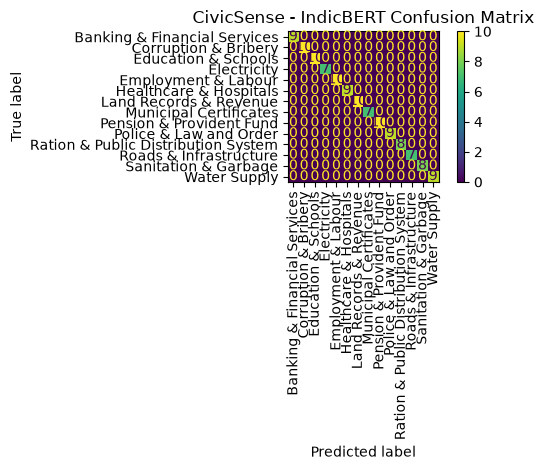

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions on test set
pred_output = trainer.predict(test_dataset)
predictions = np.argmax(pred_output.predictions, axis=1)

# Confusion matrix
cm = confusion_matrix(
    test_labels,
    predictions,
    labels=list(range(len(labels)))
)

plt.figure(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    xticks_rotation=90,
    values_format="d"
)

plt.title("CivicSense - IndicBERT Confusion Matrix")
plt.tight_layout()
plt.show()

In [8]:
def predict_category(complaint):
    
    inputs = tokenizer(
        complaint,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    
    # Move inputs to GPU
    inputs = {key: value.to(model.device) for key, value in inputs.items()}
    
    model.eval()
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    probabilities = torch.softmax(outputs.logits, dim=1)
    predicted_id = torch.argmax(probabilities, dim=1).item()
    
    category = id2label[predicted_id]
    confidence = probabilities[0][predicted_id].item()
    
    return category, confidence


# Test complaints
test_complaints = [
    "Mere area mein 3 din se bijli nahi aa rahi hai.",
    "Hamare ward mein bahut kachra jama hai aur safai nahi ho rahi.",
    "Meri pension abhi tak bank account mein nahi aayi.",
    "Patwari meri zameen ke documents ka kaam nahi kar raha.",
    "Mere area mein ek hafte se paani ki supply nahi ho rahi hai.",
    "Police station mein meri FIR darj nahi ki ja rahi hai."
]

for complaint in test_complaints:
    category, confidence = predict_category(complaint)
    
    print("\nComplaint:", complaint)
    print("Predicted Category:", category)
    print("Confidence:", round(confidence * 100, 2), "%")


Complaint: Mere area mein 3 din se bijli nahi aa rahi hai.
Predicted Category: Electricity
Confidence: 34.0 %

Complaint: Hamare ward mein bahut kachra jama hai aur safai nahi ho rahi.
Predicted Category: Sanitation & Garbage
Confidence: 20.98 %

Complaint: Meri pension abhi tak bank account mein nahi aayi.
Predicted Category: Pension & Provident Fund
Confidence: 26.03 %

Complaint: Patwari meri zameen ke documents ka kaam nahi kar raha.
Predicted Category: Corruption & Bribery
Confidence: 12.13 %

Complaint: Mere area mein ek hafte se paani ki supply nahi ho rahi hai.
Predicted Category: Electricity
Confidence: 16.69 %

Complaint: Police station mein meri FIR darj nahi ki ja rahi hai.
Predicted Category: Police & Law and Order
Confidence: 30.68 %


In [9]:
def predict_top3(complaint):
    
    inputs = tokenizer(
        complaint,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    
    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }
    
    model.eval()
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    probabilities = torch.softmax(outputs.logits, dim=1)[0]
    
    top_probs, top_ids = torch.topk(probabilities, 3)
    
    print("\nComplaint:", complaint)
    print("\nTop Predictions:")
    
    for prob, idx in zip(top_probs, top_ids):
        print(
            f"{id2label[idx.item()]} "
            f"→ {prob.item() * 100:.2f}%"
        )

In [10]:
predict_top3(
    "Patwari meri zameen ke documents ka kaam nahi kar raha."
)

predict_top3(
    "Mere area mein ek hafte se paani ki supply nahi ho rahi hai."
)


Complaint: Patwari meri zameen ke documents ka kaam nahi kar raha.

Top Predictions:
Corruption & Bribery → 12.13%
Sanitation & Garbage → 10.12%
Education & Schools → 9.61%

Complaint: Mere area mein ek hafte se paani ki supply nahi ho rahi hai.

Top Predictions:
Electricity → 16.69%
Water Supply → 13.54%
Roads & Infrastructure → 10.15%


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

category_keywords = {}

for category in sorted(df["category"].unique()):
    texts = df[df["category"] == category]["clean_text"]

    vectorizer = TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        max_features=15
    )

    vectorizer.fit(texts)

    keywords = vectorizer.get_feature_names_out()
    category_keywords[category] = list(keywords)

    print(f"\n{category}")
    print(", ".join(keywords))


Banking & Financial Services
ho raha, kaam, kaam nahi, kar rahe, nahi, nahi kar, se, staff kaam, update, आव, आव दन, दन, दस, दस रह, रह

Corruption & Bribery
hai, ke, mein, sir, गए, झस, झस रम, पए, पए गए, पत, पत बनव, बनव, रम, रम पत, लय

Education & Schools
bahut, chuka, distribute, government, government school, hai, hain, ho, ho chuka, hui, hui session, mein, mein books, school, session shuru

Electricity
aaya, aaya bijli, bhi, bijli, hai, ho, li, mein, mein bill, meter, meter reading, reading galat, sahi, sahi hai, zyada

Employment & Labour
construction, contract worker, hai, ka, nahi, sir, तन, तन नह, नतम, नतम तन, नह, नह रह, मजद, मजद नतम, रह

Healthcare & Hospitals
available, bank, blood, blood bank, blood group, delay, delay se, dikkat, emergency mein, group, group available, hui, mein, nahi, se

Land Records & Revenue
baad, baad bhi, bhi khasra, hua, ke baad, khasra number, sir, जम, नव, नव नह, नह, नह रह, पटव, पटव नव, रह

Municipal Certificates
certificate, certificate apply, death c

In [12]:
# Domain-specific keyword rules for CivicSense

keyword_rules = {
    "Electricity": [
        "bijli", "electricity", "meter", "meter reading",
        "power cut", "power", "transformer", "electric bill"
    ],

    "Water Supply": [
        "paani", "water", "drinking water",
        "water supply", "pipeline", "nal", "pani"
    ],

    "Land Records & Revenue": [
        "patwari", "zameen", "khasra",
        "khasra number", "land record", "land records",
        "jamabandi", "mutation"
    ],

    "Sanitation & Garbage": [
        "kachra", "safai", "garbage",
        "waste", "municipal safai"
    ],

    "Municipal Certificates": [
        "death certificate", "birth certificate",
        "certificate", "municipal certificate"
    ],

    "Banking & Financial Services": [
        "bank", "passbook", "account",
        "bank branch", "transaction"
    ],

    "Education & Schools": [
        "school", "government school",
        "books", "teacher", "student",
        "school fees", "education"
    ],

    "Police & Law and Order": [
        "police", "fir", "FIR",
        "police station", "thana", "thane",
        "complaint to police"
    ],

    "Pension & Provident Fund": [
        "pension", "provident fund",
        "PF", "pension payment"
    ],

    "Ration & Public Distribution System": [
        "ration", "ration dealer",
        "ration card", "anaj", "food grain",
        "public distribution"
    ],

    "Healthcare & Hospitals": [
        "hospital", "doctor", "medicine",
        "blood bank", "blood", "treatment",
        "healthcare", "medical"
    ],

    "Employment & Labour": [
        "job", "employment", "worker",
        "labour", "labor", "salary",
        "contract worker", "construction worker"
    ],

    "Corruption & Bribery": [
        "bribe", "bribery", "corruption",
        "rishwat", "paise leta", "paise maang"
    ],

    "Roads & Infrastructure": [
        "road", "roads", "sadak",
        "pothole", "bridge", "street light",
        "infrastructure"
    ]
}


def hybrid_predict(complaint):

    # ---------- IndicBERT prediction ----------
    inputs = tokenizer(
        complaint,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=1)[0]

    bert_id = torch.argmax(probabilities).item()
    bert_category = id2label[bert_id]
    bert_confidence = probabilities[bert_id].item()


    # ---------- Keyword matching ----------
    text = complaint.lower()

    keyword_scores = {}

    for category, keywords in keyword_rules.items():

        score = 0

        for keyword in keywords:
            if keyword.lower() in text:
                score += 1

        keyword_scores[category] = score


    # Category with strongest keyword match
    best_keyword_category = max(
        keyword_scores,
        key=keyword_scores.get
    )

    best_keyword_score = keyword_scores[best_keyword_category]


    # ---------- Final decision ----------
    if best_keyword_score > 0:

        final_category = best_keyword_category
        method = "Keyword + IndicBERT"

    else:

        final_category = bert_category
        method = "IndicBERT"


    return final_category, bert_confidence, method

In [13]:
from pathlib import Path
import os

MODEL_PATH = Path("../models/civicsense_indicbert").resolve()

MODEL_PATH.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(MODEL_PATH))
tokenizer.save_pretrained(str(MODEL_PATH))

print("Saved to:", MODEL_PATH)
print(os.listdir(MODEL_PATH))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: C:\Users\Dhanshree\CivicSense\CivicSense\models\civicsense_indicbert
['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']


In [15]:
# ============================================================
# IndicBERT Model Evaluation
# Classification Report + Confusion Matrix
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# Generate predictions on test dataset
# ------------------------------------------------------------

pred_output = trainer.predict(test_dataset)

predictions = np.argmax(
    pred_output.predictions,
    axis=1
)

# True labels
true_labels = np.array(test_dataset.labels)

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

report = classification_report(
    true_labels,
    predictions,
    target_names=[
        id2label[i]
        for i in range(len(id2label))
    ],
    digits=4
)

print("Classification Report")
print("=" * 70)
print(report)

Classification Report
                                     precision    recall  f1-score   support

       Banking & Financial Services     1.0000    1.0000    1.0000         9
               Corruption & Bribery     1.0000    1.0000    1.0000        10
                Education & Schools     1.0000    1.0000    1.0000        10
                        Electricity     1.0000    1.0000    1.0000         7
                Employment & Labour     1.0000    1.0000    1.0000        10
             Healthcare & Hospitals     1.0000    1.0000    1.0000         9
             Land Records & Revenue     1.0000    1.0000    1.0000        10
             Municipal Certificates     1.0000    1.0000    1.0000         7
           Pension & Provident Fund     1.0000    1.0000    1.0000        10
             Police & Law and Order     1.0000    1.0000    1.0000         9
Ration & Public Distribution System     1.0000    1.0000    1.0000         8
             Roads & Infrastructure     1.0000    1.0

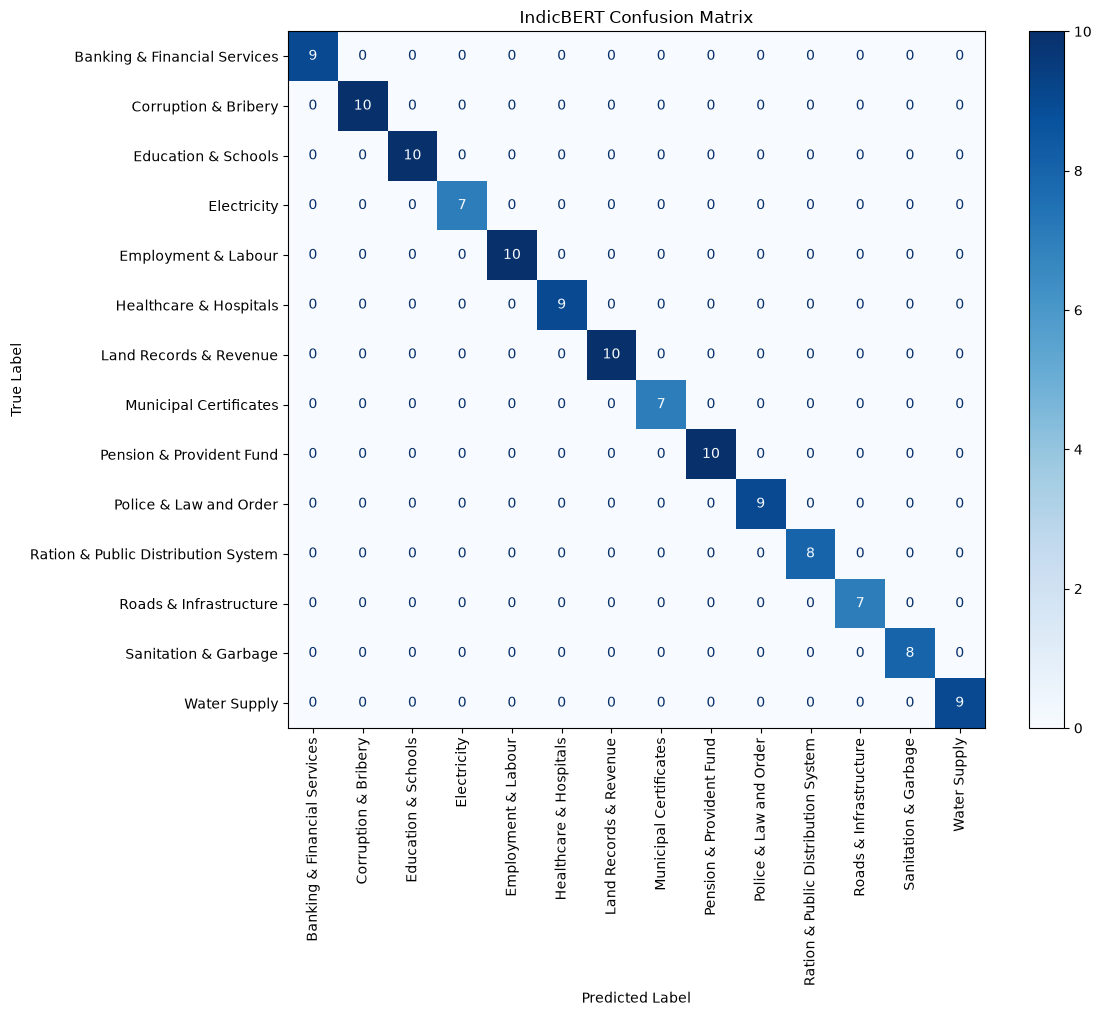

In [16]:
# ============================================================
# Confusion Matrix
# ============================================================

class_names = [
    id2label[i]
    for i in range(len(id2label))
]

cm = confusion_matrix(
    true_labels,
    predictions
)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    values_format="d"
)

plt.title("IndicBERT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.show()

In [1]:
unseen_df = pd.read_csv("../data/unseen_data.csv")

print(unseen_df.shape)
unseen_df.head()

NameError: name 'pd' is not defined

In [2]:
import pandas as pd


In [22]:
unseen_df = pd.read_csv("../data/unseen_data.csv")

print(unseen_df.shape)
unseen_df.head()
print("FIRST COMPLAINT:")
print(df["complaint"].iloc[0])

print("\nRAW REPRESENTATION:")
print(repr(df["complaint"].iloc[0]))

(98, 3)
FIRST COMPLAINT:


NameError: name 'df' is not defined

In [25]:
unseen_df = pd.read_csv("../data/unseen_data.csv", encoding="utf-8")

print("Shape:", unseen_df.shape)

print("\nFIRST COMPLAINT:")
print(unseen_df["complaint"].iloc[0])

print("\nRAW REPRESENTATION:")
print(repr(unseen_df["complaint"].iloc[0]))

print("\nContains Hindi:",
      any("\u0900" <= ch <= "\u097F" for ch in unseen_df["complaint"].iloc[0]))

print("Contains ???? :",
      "?" in unseen_df["complaint"].iloc[0])

Shape: (98, 3)

FIRST COMPLAINT:


KeyError: 'complaint'

In [26]:
unseen_df = pd.read_csv("../data/unseen_data.csv", encoding="utf-8")

print("Columns:")
print(unseen_df.columns.tolist())

print("\nFirst 5 rows:")
print(unseen_df.head().to_string())

Columns:
['text', 'category', 'Unnamed: 2']

First 5 rows:
                                                                              text                      category  Unnamed: 2
0     My bank account has been frozen and the branch is not explaining the reason.  Banking & Financial Services         NaN
1       Mere bank account se paise deduct hue lekin transaction complete nahi hua.  Banking & Financial Services         NaN
2  Bank branch mein passbook update karwane ke liye bahut wait karna pad raha hai.  Banking & Financial Services         NaN
3     My ATM transaction failed but the amount was still deducted from my account.  Banking & Financial Services         NaN
4                        Bank wale meri account details update nahi kar rahe hain.  Banking & Financial Services         NaN


In [6]:
from pathlib import Path
import torch
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Load unseen dataset
unseen_df = pd.read_csv("../data/unseen_data.csv")

texts = unseen_df["text"].tolist()
true_labels = unseen_df["category"].tolist()

print("Total unseen complaints:", len(texts))

Total unseen complaints: 98


In [8]:
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Project root se model ka absolute path
MODEL_PATH = Path("../models/civicsense_indicbert").resolve()

print("Model path:", MODEL_PATH)
print("Exists:", MODEL_PATH.exists())

if MODEL_PATH.exists():
    print("Files:")
    for f in MODEL_PATH.iterdir():
        print(" -", f.name)

Model path: C:\Users\Dhanshree\CivicSense\CivicSense\models\civicsense_indicbert
Exists: True
Files:
 - config.json
 - model.safetensors
 - tokenizer.json
 - tokenizer_config.json
 - training_args.bin


In [10]:
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_PATH = Path("../models/civicsense_indicbert").resolve()

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    str(MODEL_PATH),
    trust_remote_code=True
)

# Load trained model
model = AutoModelForSequenceClassification.from_pretrained(
    str(MODEL_PATH),
    trust_remote_code=True
)

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

# Label mapping
id2label = {
    int(key): value
    for key, value in model.config.id2label.items()
}

print("Model loaded successfully!")
print("Device:", device)
print("Number of classes:", len(id2label))
print("Categories:", list(id2label.values()))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully!
Device: cuda
Number of classes: 14
Categories: ['Banking & Financial Services', 'Corruption & Bribery', 'Education & Schools', 'Electricity', 'Employment & Labour', 'Healthcare & Hospitals', 'Land Records & Revenue', 'Municipal Certificates', 'Pension & Provident Fund', 'Police & Law and Order', 'Ration & Public Distribution System', 'Roads & Infrastructure', 'Sanitation & Garbage', 'Water Supply']


In [11]:
predicted_labels = []
predicted_confidences = []

model.eval()

for text in texts:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=1)[0]

    predicted_id = torch.argmax(probabilities).item()
    confidence = probabilities[predicted_id].item()

    predicted_labels.append(id2label[predicted_id])
    predicted_confidences.append(confidence)

print("Predictions completed!")
print("Total predictions:", len(predicted_labels))

Predictions completed!
Total predictions: 98


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)
recall = recall_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)
macro_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

print("===== UNSEEN DATASET RESULTS =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        true_labels,
        predicted_labels,
        zero_division=0
    )
)

===== UNSEEN DATASET RESULTS =====
Accuracy : 0.7041
Precision: 0.7163
Recall   : 0.7041
Macro F1 : 0.6896

===== CLASSIFICATION REPORT =====
                                     precision    recall  f1-score   support

       Banking & Financial Services       1.00      0.57      0.73         7
               Corruption & Bribery       0.57      0.57      0.57         7
                Education & Schools       1.00      0.86      0.92         7
                        Electricity       0.75      0.43      0.55         7
                Employment & Labour       0.50      1.00      0.67         7
             Healthcare & Hospitals       1.00      1.00      1.00         7
             Land Records & Revenue       0.71      0.71      0.71         7
             Municipal Certificates       0.83      0.71      0.77         7
           Pension & Provident Fund       0.46      0.86      0.60         7
             Police & Law and Order       1.00      1.00      1.00         7
Ration & P

In [14]:
results_df = pd.DataFrame({
    "text": texts,
    "actual": true_labels,
    "predicted": predicted_labels,
    "confidence": predicted_confidences
})

wrong_df = results_df[
    results_df["actual"] != results_df["predicted"]
].copy()

print("Total unseen complaints:", len(results_df))
print("Incorrect predictions:", len(wrong_df))
print("Correct predictions:", len(results_df) - len(wrong_df))

wrong_df

Total unseen complaints: 98
Incorrect predictions: 29
Correct predictions: 69


,text,actual,predicted,confidence
0,My bank account has been frozen and the branch...,Banking & Financial Services,Pension & Provident Fund,0.112498
3,My ATM transaction failed but the amount was s...,Banking & Financial Services,Pension & Provident Fund,0.124487
5,Mere account mein online transfer ka paisa abh...,Banking & Financial Services,Pension & Provident Fund,0.156475
7,The officer asked me for extra money to proces...,Corruption & Bribery,Pension & Provident Fund,0.122172
11,The official will not complete my work unless ...,Corruption & Bribery,Employment & Labour,0.139445
13,I was asked to pay a bribe for a service that ...,Corruption & Bribery,Pension & Provident Fund,0.084266
19,The school is charging students an unauthorize...,Education & Schools,Pension & Provident Fund,0.091572
21,Our locality has been facing frequent power cu...,Electricity,Water Supply,0.134120
23,The electricity meter at my house is showing i...,Electricity,Employment & Labour,0.140103
24,Transformer failure has left several houses wi...,Electricity,Employment & Labour,0.140500


In [27]:
hindi_rows = unseen_df[
    unseen_df["text"].astype(str).apply(
        lambda x: any("\u0900" <= ch <= "\u097F" for ch in x)
    )
]

print("Number of Hindi rows:", len(hindi_rows))

print("\nHindi examples:")
print(hindi_rows["text"].head(10).to_string(index=False))

Number of Hindi rows: 0

Hindi examples:
Series([], )


In [28]:
import pandas as pd

grievances_df = pd.read_csv("../data/grievances.csv", encoding="utf-8")

print("Columns:")
print(grievances_df.columns.tolist())

print("\nShape:")
print(grievances_df.shape)

print("\nFirst 5 rows:")
print(grievances_df.head().to_string())

Columns:
['grievance_id', 'text']

Shape:
(614, 2)

First 5 rows:
  grievance_id                                                                                                                            text
0   GRVH900075               Sir/Madam, Patna mein bijli two weeks se gayab h, transformer kharab ho gaya lagta hai. ????? ???? ???????? ?????
1   GRVH900500               Namaste sir, Ration dealer Adhartal mein har mahine paise leta hai anaj dene ke liye, complaint dena chahta hoon.
2   GRVH900036                                      Drinking water contaminated hai Sector 7 mein, please send sample testing team. Thank you.
3   GRVH900436  Passbook update Model Town bank branch mein two weeks se nahi ho raha, staff kaam nahi kar rahe. Bahut pareshaan hain hum log.
4   GRVH900160      ?????, Mohd. Salim ki pension 3 days se nahi mili hai, bank account Wright Town branch mein hai. ????? ???? ???????? ?????


In [15]:
# Reload updated predictor.py
import sys
from pathlib import Path

PROJECT_ROOT = Path("../").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.predictor import predict_batch

# Run hybrid predictions
hybrid_results = predict_batch(texts, batch_size=16)

hybrid_predicted_labels = [
    result["category"] for result in hybrid_results
]

hybrid_confidences = [
    result["confidence"] for result in hybrid_results
]

print("Hybrid predictions completed!")
print("Total predictions:", len(hybrid_predicted_labels))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Hybrid predictions completed!
Total predictions: 98


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

hybrid_accuracy = accuracy_score(
    true_labels,
    hybrid_predicted_labels
)

hybrid_precision = precision_score(
    true_labels,
    hybrid_predicted_labels,
    average="macro",
    zero_division=0
)

hybrid_recall = recall_score(
    true_labels,
    hybrid_predicted_labels,
    average="macro",
    zero_division=0
)

hybrid_f1 = f1_score(
    true_labels,
    hybrid_predicted_labels,
    average="macro",
    zero_division=0
)

print("===== HYBRID UNSEEN RESULTS =====")
print(f"Accuracy : {hybrid_accuracy:.4f}")
print(f"Precision: {hybrid_precision:.4f}")
print(f"Recall   : {hybrid_recall:.4f}")
print(f"Macro F1 : {hybrid_f1:.4f}")

print("\n===== HYBRID CLASSIFICATION REPORT =====")
print(
    classification_report(
        true_labels,
        hybrid_predicted_labels,
        zero_division=0
    )
)

===== HYBRID UNSEEN RESULTS =====
Accuracy : 0.9490
Precision: 0.9561
Recall   : 0.9490
Macro F1 : 0.9484

===== HYBRID CLASSIFICATION REPORT =====
                                     precision    recall  f1-score   support

       Banking & Financial Services       0.78      1.00      0.88         7
               Corruption & Bribery       0.86      0.86      0.86         7
                Education & Schools       1.00      1.00      1.00         7
                        Electricity       1.00      1.00      1.00         7
                Employment & Labour       0.88      1.00      0.93         7
             Healthcare & Hospitals       1.00      1.00      1.00         7
             Land Records & Revenue       1.00      0.86      0.92         7
             Municipal Certificates       1.00      1.00      1.00         7
           Pension & Provident Fund       1.00      0.71      0.83         7
             Police & Law and Order       1.00      1.00      1.00         7
Rati

CivicSense Hybrid Evaluation
Accuracy : 0.9490
Precision: 0.9561
Recall   : 0.9490
Macro F1 : 0.9484

Classification Report:
                                     precision    recall  f1-score   support

       Banking & Financial Services       0.78      1.00      0.88         7
               Corruption & Bribery       0.86      0.86      0.86         7
                Education & Schools       1.00      1.00      1.00         7
                        Electricity       1.00      1.00      1.00         7
                Employment & Labour       0.88      1.00      0.93         7
             Healthcare & Hospitals       1.00      1.00      1.00         7
             Land Records & Revenue       1.00      0.86      0.92         7
             Municipal Certificates       1.00      1.00      1.00         7
           Pension & Provident Fund       1.00      0.71      0.83         7
             Police & Law and Order       1.00      1.00      1.00         7
Ration & Public Distributio

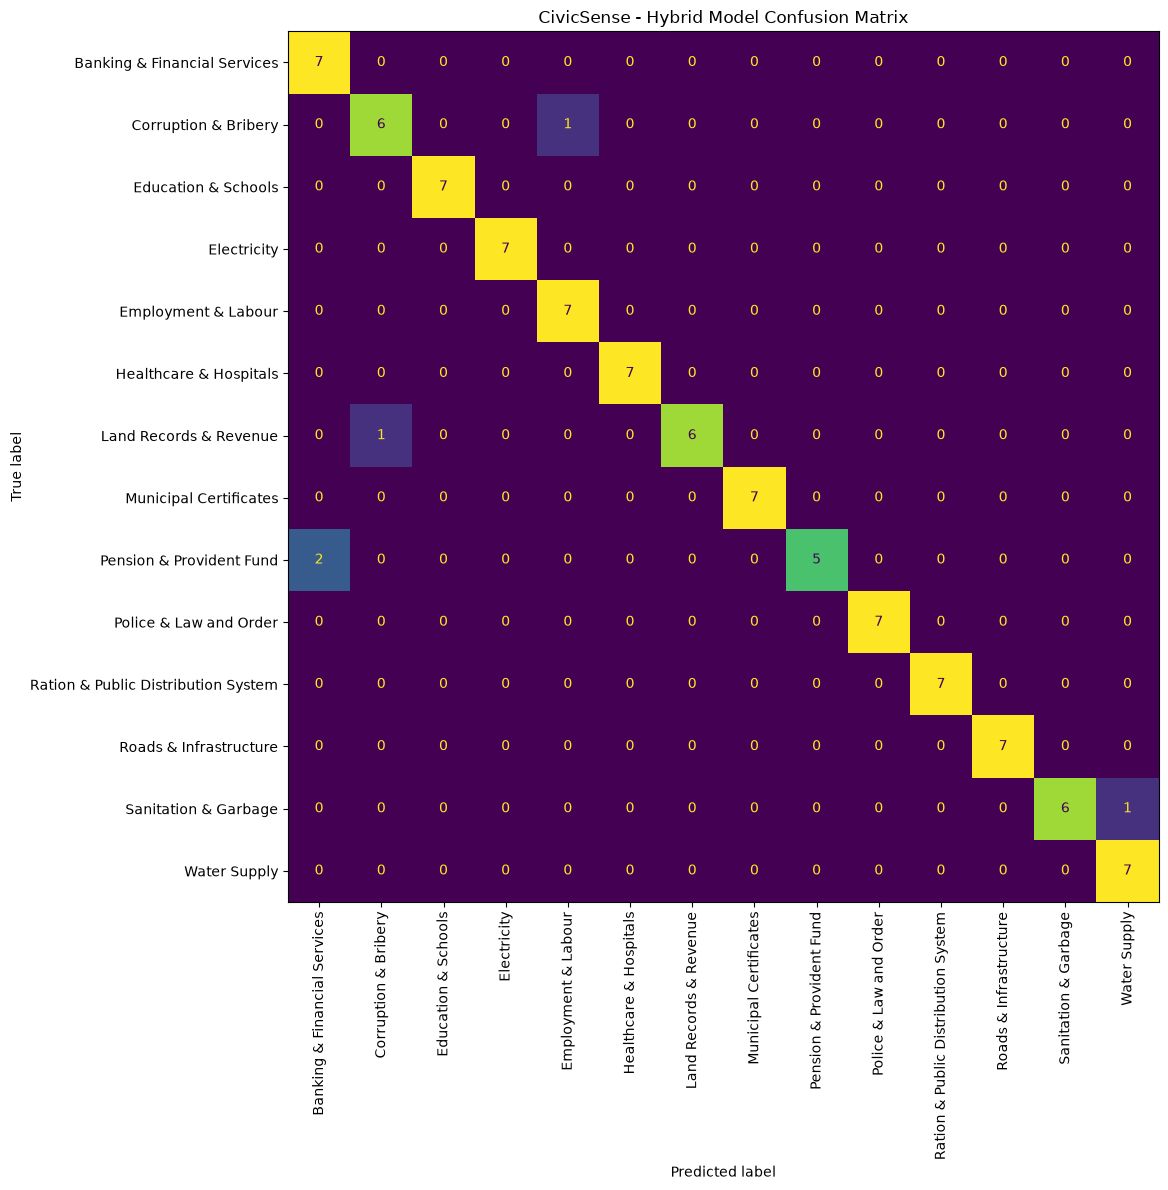

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import pandas as pd
import matplotlib.pyplot as plt

# Hybrid predictions
results = predict_batch(texts, batch_size=16)

pred_labels = [r["category"] for r in results]

# Overall metrics
accuracy = accuracy_score(true_labels, pred_labels)
precision = precision_score(
    true_labels, pred_labels,
    average="macro",
    zero_division=0
)
recall = recall_score(
    true_labels, pred_labels,
    average="macro",
    zero_division=0
)
macro_f1 = f1_score(
    true_labels, pred_labels,
    average="macro",
    zero_division=0
)

print("CivicSense Hybrid Evaluation")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")

# Detailed classification report
report = classification_report(
    true_labels,
    pred_labels,
    zero_division=0
)

print("\nClassification Report:")
print(report)

# Confusion matrix
labels = sorted(unseen_df["category"].unique())

cm = confusion_matrix(
    true_labels,
    pred_labels,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(14, 12))
disp.plot(
    ax=ax,
    xticks_rotation=90,
    colorbar=False
)

plt.title("CivicSense - Hybrid Model Confusion Matrix")
plt.tight_layout()
plt.show()

In [18]:
from pathlib import Path
import pandas as pd

# Create results folder
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# Overall results
evaluation_results = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "IndicBERT",
        "IndicBERT + Keyword Hybrid"
    ],
    "Accuracy": [
        1.0000,
        0.7041,
        0.9490
    ],
    "Precision": [
        1.0000,
        0.7163,
        0.9561
    ],
    "Recall": [
        1.0000,
        0.7041,
        0.9490
    ],
    "Macro F1": [
        1.0000,
        0.6896,
        0.9484
    ]
})

evaluation_results

,Model,Accuracy,Precision,Recall,Macro F1
0,TF-IDF + Logistic Regression,1.0000,1.0000,1.0000,1.0000
1,IndicBERT,0.7041,0.7163,0.7041,0.6896
2,IndicBERT + Keyword Hybrid,0.9490,0.9561,0.9490,0.9484


In [20]:
evaluation_results.to_csv(
    results_dir / "evaluation_results.csv",
    index=False
)

print("Saved:", results_dir / "evaluation_results.csv")

Saved: ..\results\evaluation_results.csv


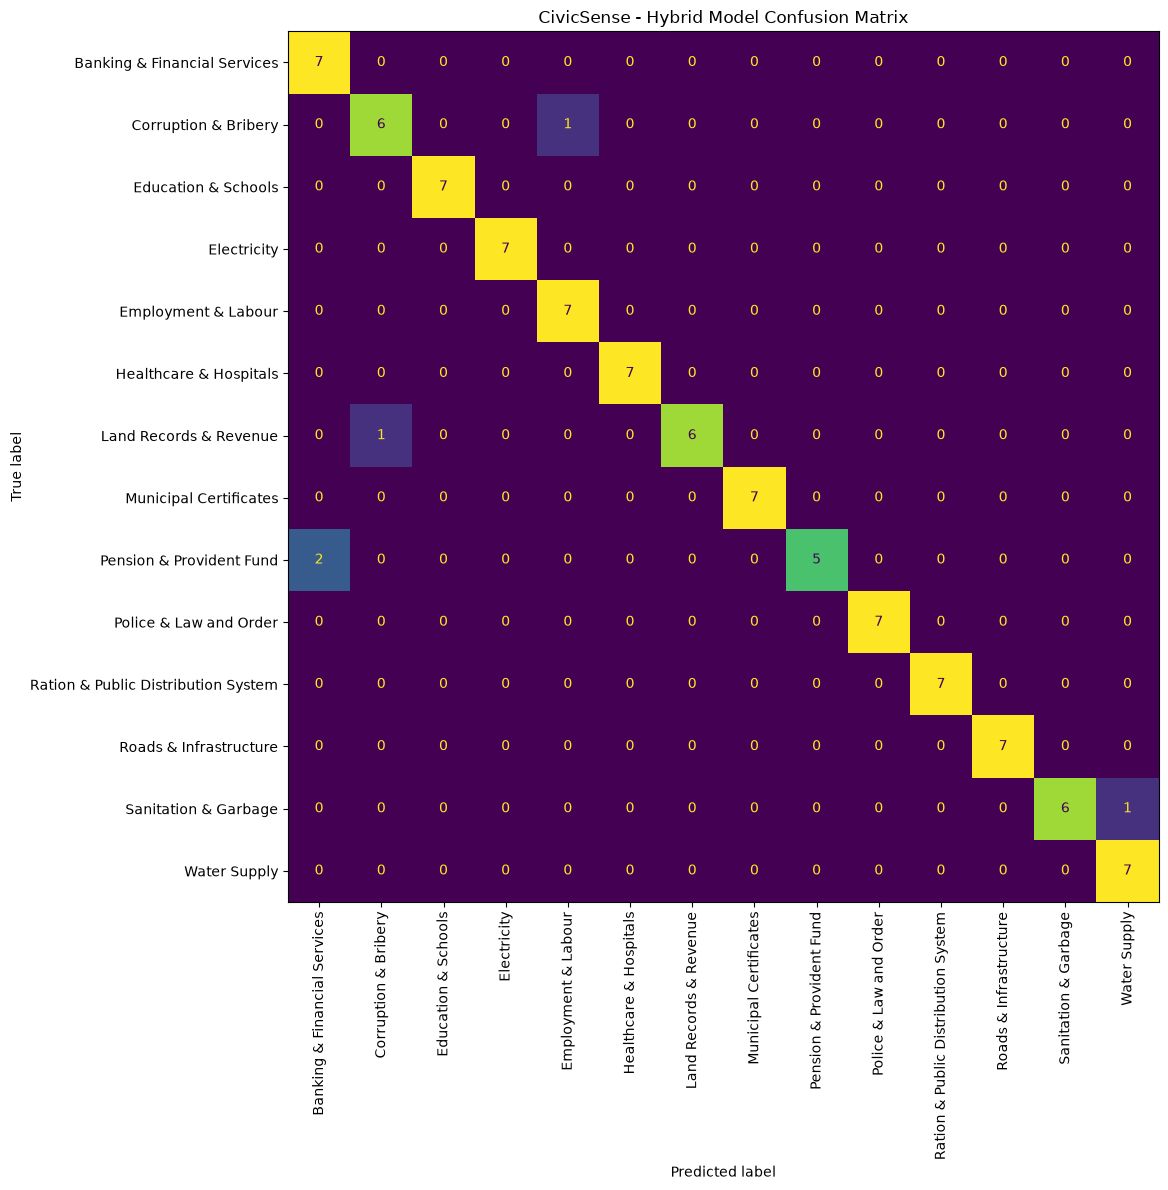

Saved: ..\results\confusion_matrix.png


In [21]:
fig, ax = plt.subplots(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    colorbar=False
)

plt.title("CivicSense - Hybrid Model Confusion Matrix")
plt.tight_layout()

plt.savefig(
    results_dir / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", results_dir / "confusion_matrix.png")